# EDA Assignment Questions

## Dataset 1: Bike Details Dataset

1. What is the range of selling prices in the dataset?
2. What is the median selling price for bikes in the dataset?
3. What is the most common seller type?
4. How many bikes have driven more than 50,000 kilometers?
5. What is the average `km_driven` value for each ownership type?
6. What proportion of bikes are from the year 2015 or older?
7. What is the trend of missing values across the dataset?
8. What is the highest `ex_showroom_price` recorded, and for which bike?
9. What is the total number of bikes listed by each seller type?
10. What is the relationship between `selling_price` and `km_driven` for first-owner bikes?
11. Identify and remove outliers in the `km_driven` column using the IQR method.
12. Perform a bivariate analysis to visualize the relationship between year and `selling_price`.
13. What is the average depreciation in selling price based on the bike's age (`current year - manufacturing year`)?
14. Which bike names are priced significantly above the average price for their manufacturing year?
15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.

---

## Dataset 2: Car Sale Dataset

1. What is the average selling price of cars for each dealer, and how does it compare across different dealers?
2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?
3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?
4. What is the distribution of car prices across different regions?
5. What is the distribution of cars based on body styles?
6. How does the average selling price of cars vary by customer gender and annual income?
7. What is the distribution of car prices by region, and how does the number of cars sold vary by region?
8. How does the average car price differ between cars with different engine sizes?
9. How do car prices vary based on the customer’s annual income bracket?
10. What are the top 5 car models with the highest number of sales, and how does their price distribution look?
11. How does car price vary with engine size across different car colors, and which colors have the highest price variation?
12. Is there any seasonal trend in car sales based on the date of sale?
13. How does the car price distribution change when considering different combinations of body style and transmission type?
14. What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?
15. How does the average car price vary across different car models and engine types?

---

## Dataset 3: Amazon Sales Data

1. What is the average rating for each product category?
2. What are the top `rating_count` products by category?
3. What is the distribution of discounted prices vs. actual prices?
4. How does the average discount percentage vary across categories?
5. What are the most popular product names?
6. What are the most popular product keywords?
7. What are the most popular product reviews?
8. What is the correlation between `discounted_price` and `rating`?
9. What are the Top 5 categories based on the highest ratings?
10. Identify any potential areas for improvement or optimization based on the data analysis.

---

## Dataset 4: Spotify Data (Popular Hip-Hop Artists and Tracks)

1. Read the dataframe, check null values (if present handle them), and check duplicate rows (if present handle them).
2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.
3. Is there any relationship between popularity and the duration of tracks? Explore using a scatter plot.
4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.
5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.
6. Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist.
7. For the top 5 most popular artists, what are their most popular tracks? List the track names for each artist.
8. Visualize relationships between multiple numerical variables simultaneously using a pair plot.
9. Does the duration of tracks vary significantly across different artists? Explore visually using a box plot or violin plot.
10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or violin plot.


In [4]:
# Import necessary libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Bike Details dataset
bike_df = pd.read_csv('datasets/BIKE DETAILS.csv')
bike_df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [5]:
# Initial exploration of Bike Details dataset
bike_df.info()
bike_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.1+ KB


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
count,1061,1061.000000,1061.000000,1061,1061,1061.000000,6.260000e+02
unique,279,NaN,NaN,2,4,NaN,NaN
top,Bajaj Pulsar 150,NaN,NaN,Individual,1st owner,NaN,NaN
freq,41,NaN,NaN,1055,924,NaN,NaN
mean,NaN,59638.151744,2013.867107,NaN,NaN,34359.833176,8.795871e+04
std,NaN,56304.291973,4.301191,NaN,NaN,51623.152702,7.749659e+04
min,NaN,5000.000000,1988.000000,NaN,NaN,350.000000,3.049000e+04
25%,NaN,28000.000000,2011.000000,NaN,NaN,13500.000000,5.485200e+04
50%,NaN,45000.000000,2015.000000,NaN,NaN,25000.000000,7.275250e+04
75%,NaN,70000.000000,2017.000000,NaN,NaN,43000.000000,8.703150e+04


In [6]:
# Q1: What is the range of selling prices in the dataset?
selling_price_range = (bike_df['selling_price'].min(), bike_df['selling_price'].max())
print(f"Range of selling prices: {selling_price_range}")

Range of selling prices: (5000, 760000)


In [7]:
# Q2: What is the median selling price for bikes in the dataset?
median_selling_price = bike_df['selling_price'].median()
print(f"Median selling price: {median_selling_price}")

Median selling price: 45000.0


In [8]:
# Q3: Most common seller type
most_common_seller = bike_df['seller_type'].mode()[0]
print(f'Most common seller type: {most_common_seller}')

Most common seller type: Individual


In [9]:
# Q4: Bikes driven more than 50,000 km
count_50k = (bike_df['km_driven'] > 50000).sum()
print(f'Bikes driven >50,000 km: {count_50k}')

Bikes driven >50,000 km: 170


In [10]:
# Q5: Average km_driven by ownership type
avg_km_by_owner = bike_df.groupby('owner')['km_driven'].mean()
print(avg_km_by_owner)

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64


In [11]:
# Q6: Proportion of bikes from 2015 or older
prop_2015_older = (bike_df['year'] <= 2015).mean()
print(f'Proportion from 2015 or older: {prop_2015_older:.2%}')

Proportion from 2015 or older: 56.64%


In [12]:
# Q7: Trend of missing values
missing_trend = bike_df.isnull().sum()
print(missing_trend)

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


In [13]:
# Q8: Highest ex_showroom_price and bike
max_ex_showroom = bike_df['ex_showroom_price'].max()
bike_max_ex = bike_df.loc[bike_df['ex_showroom_price'] == max_ex_showroom, 'name'].values
print(f'Highest ex_showroom_price: {max_ex_showroom}, Bike: {bike_max_ex}')

Highest ex_showroom_price: 1278000.0, Bike: ['Harley-Davidson Street Bob']


In [14]:
# Q9: Total bikes listed by seller type
seller_counts = bike_df['seller_type'].value_counts()
print(seller_counts)

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


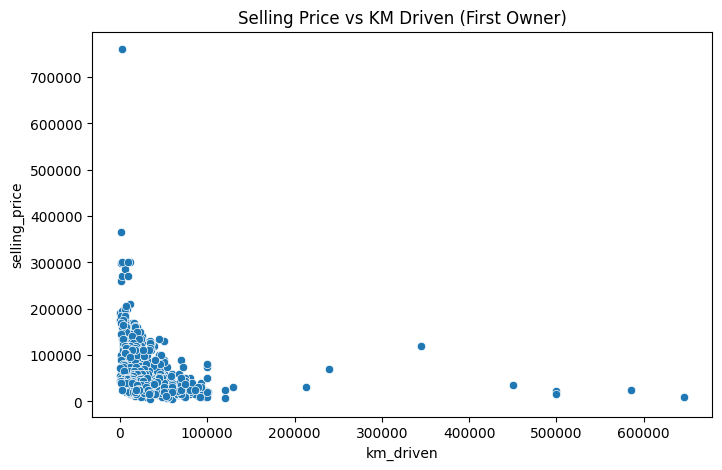

In [15]:
# Q10: Relationship between selling_price and km_driven for first-owner bikes
first_owner = bike_df[bike_df['owner'] == '1st owner']
plt.figure(figsize=(8,5))
sns.scatterplot(data=first_owner, x='km_driven', y='selling_price')
plt.title('Selling Price vs KM Driven (First Owner)')
plt.show()

In [16]:
# Q11: Remove outliers in km_driven using IQR
Q1 = bike_df['km_driven'].quantile(0.25)
Q3 = bike_df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
filtered_bike_df = bike_df[(bike_df['km_driven'] >= lower) & (bike_df['km_driven'] <= upper)]
print(f'Rows after outlier removal: {filtered_bike_df.shape[0]}')

Rows after outlier removal: 1022


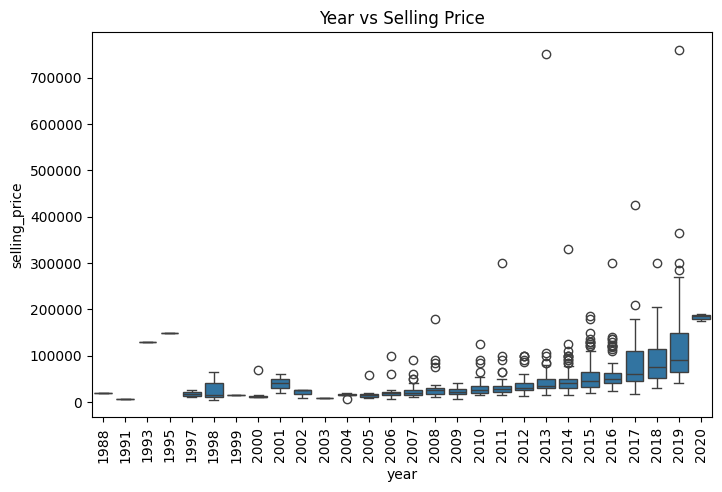

In [17]:
# Q12: Bivariate analysis - year vs selling_price
plt.figure(figsize=(8,5))
sns.boxplot(data=bike_df, x='year', y='selling_price')
plt.xticks(rotation=90)
plt.title('Year vs Selling Price')
plt.show()

In [18]:
# Q13: Average depreciation in selling price based on age
current_year = 2025
bike_df['age'] = current_year - bike_df['year']
avg_depreciation = bike_df.groupby('age')['selling_price'].mean().diff().mean()
print(f'Average depreciation per year: {avg_depreciation:.2f}')

Average depreciation per year: -6049.38


In [19]:
# Q14: Bikes priced above average for their year
avg_price_by_year = bike_df.groupby('year')['selling_price'].mean()
above_avg_bikes = bike_df[bike_df.apply(lambda x: x['selling_price'] > avg_price_by_year[x['year']], axis=1)]
print(above_avg_bikes[['name', 'year', 'selling_price']])

                                      name  year  selling_price
0                Royal Enfield Classic 350  2019         175000
2      Royal Enfield Classic Gunmetal Grey  2018         150000
3        Yamaha Fazer FI V 2.0 [2016-2018]  2015          65000
7     Royal Enfield Bullet 350 [2007-2011]  2008         180000
13                           Yamaha YZF R3  2019         365000
...                                    ...   ...            ...
1004                  Bajaj Pulsar  NS 200  2016          60000
1005                    TVS Apache RTR 160  2014          60000
1008                    Bajaj Pulsar 220 F  2012          52000
1012                   Bajaj Pulsar NS 200  2014          50000
1023                Bajaj Avenger 220 dtsi  2012          45000

[334 rows x 3 columns]


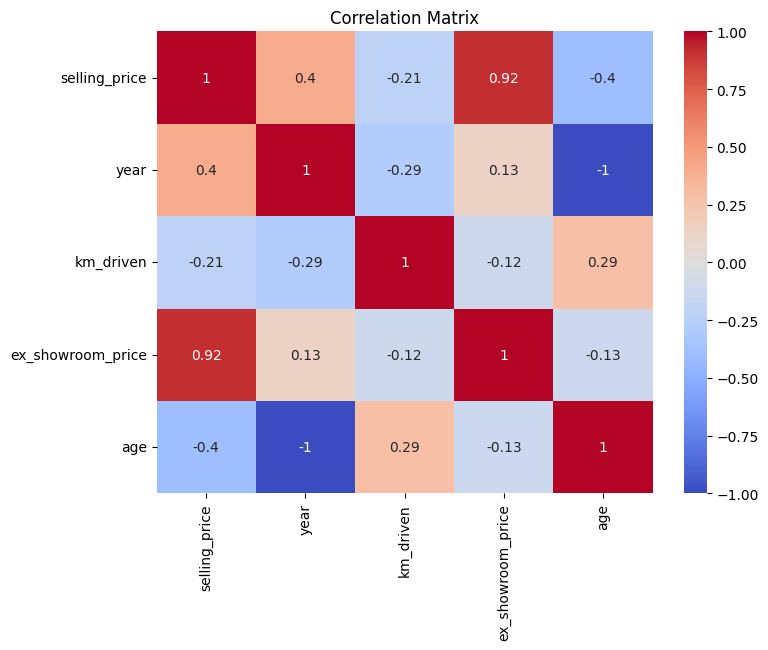

In [20]:
# Q15: Correlation matrix and heatmap
corr = bike_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

---
## Dataset 2: Car Sale Dataset

In [21]:
# Load Car Sale dataset
car_df = pd.read_csv('datasets/Car Sale.csv')
car_df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [22]:
# Q1: Average selling price of cars for each dealer
avg_price_dealer = car_df.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending=False)
print(avg_price_dealer)

Dealer_Name
U-Haul CO                                          28769.919006
Classic Chevy                                      28602.014446
Rabun Used Car Sales                               28527.536177
Iceberg Rentals                                    28522.958533
Enterprise Rent A Car                              28312.580800
Scrivener Performance Engineering                  28297.371589
Gartner Buick Hyundai Saab                         28247.621019
Saab-Belle Dodge                                   28190.139888
Capitol KIA                                        28189.703822
Race Car Help                                      28163.372706
Chrysler of Tri-Cities                             28123.091054
Star Enterprises Inc                               28113.055244
Suburban Ford                                      28112.206758
C & M Motors Inc                                   28111.755200
Tri-State Mack Inc                                 28095.562050
Pars Auto Sales             

In [23]:
# Q2: Car brand with highest price variation
price_var = car_df.groupby('Company')['Price ($)'].std().sort_values(ascending=False)
print(price_var.head())

Company
Lincoln     19658.050211
Saab        19653.740089
Cadillac    19517.120220
Plymouth    19065.997338
Lexus       17852.923492
Name: Price ($), dtype: float64


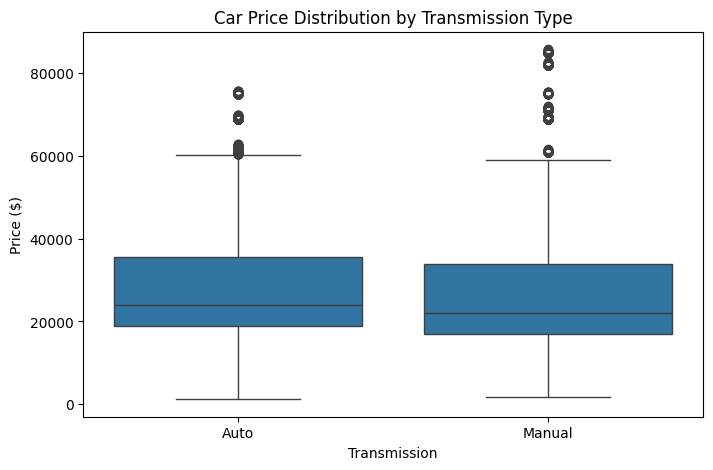

In [24]:
# Q3: Distribution of car prices for each transmission type
plt.figure(figsize=(8,5))
sns.boxplot(data=car_df, x='Transmission', y='Price ($)')
plt.title('Car Price Distribution by Transmission Type')
plt.show()

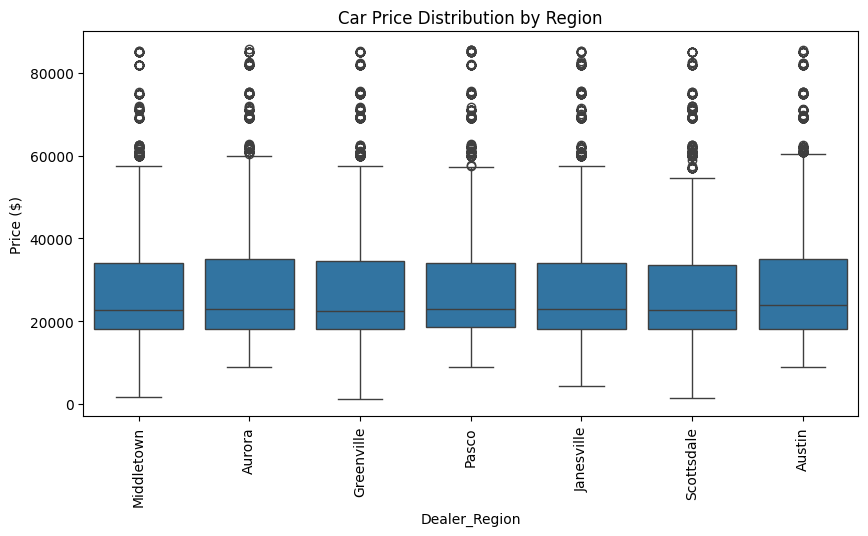

In [25]:
# Q4: Distribution of car prices across regions
plt.figure(figsize=(10,5))
sns.boxplot(data=car_df, x='Dealer_Region', y='Price ($)')
plt.xticks(rotation=90)
plt.title('Car Price Distribution by Region')
plt.show()

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64


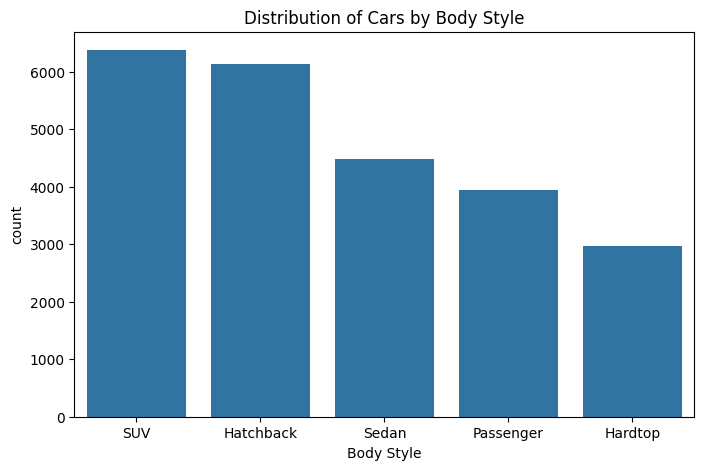

In [26]:
# Q5: Distribution of cars based on body styles
body_style_counts = car_df['Body Style'].value_counts()
print(body_style_counts)
plt.figure(figsize=(8,5))
sns.countplot(data=car_df, x='Body Style', order=body_style_counts.index)
plt.title('Distribution of Cars by Body Style')
plt.show()

In [27]:
# Q6: Average selling price by gender and annual income
avg_price_gender_income = car_df.groupby(['Gender', 'Annual Income'])['Price ($)'].mean().unstack(0)
print(avg_price_gender_income)

Gender               Female          Male
Annual Income                            
10080                   NaN  22801.000000
13500          28132.038732  27809.493111
24000                   NaN  61001.000000
85000                   NaN  43000.000000
106000         46001.000000           NaN
...                     ...           ...
6600000                 NaN  39000.000000
6800000                 NaN  15000.000000
7650000                 NaN  21000.000000
8000000                 NaN  85000.000000
11200000                NaN  26001.000000

[2508 rows x 2 columns]


In [28]:
# Q7: Distribution of car prices and number sold by region
region_price = car_df.groupby('Dealer_Region')['Price ($)'].mean()
region_count = car_df['Dealer_Region'].value_counts()
print(region_price)
print(region_count)

Dealer_Region
Aurora        28334.626837
Austin        28341.603628
Greenville    28180.819054
Janesville    27833.350955
Middletown    27856.338875
Pasco         28119.039923
Scottsdale    27954.958928
Name: Price ($), dtype: float64
Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Middletown    3128
Greenville    3128
Name: count, dtype: int64


In [29]:
# Q8: Average car price by engine size
engine_price = car_df.groupby('Engine')['Price ($)'].mean().sort_values(ascending=False)
print(engine_price)

Engine
DoubleÂ Overhead Camshaft    28248.525972
Overhead Camshaft            27914.710631
Name: Price ($), dtype: float64


In [30]:
# Q9: Car prices by annual income bracket
income_bins = pd.qcut(car_df['Annual Income'], 5)
income_price = car_df.groupby(income_bins)['Price ($)'].mean()
print(income_price)

Annual Income
(10079.999, 13500.0]       27878.018582
(13500.0, 620000.0]        28132.007163
(620000.0, 865000.0]       27834.126519
(865000.0, 1300000.0]      28468.153830
(1300000.0, 11200000.0]    28162.582432
Name: Price ($), dtype: float64


C:\Users\Piyush Mishra\AppData\Local\Temp\ipykernel_16744\3748621795.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_price = car_df.groupby(income_bins)['Price ($)'].mean()


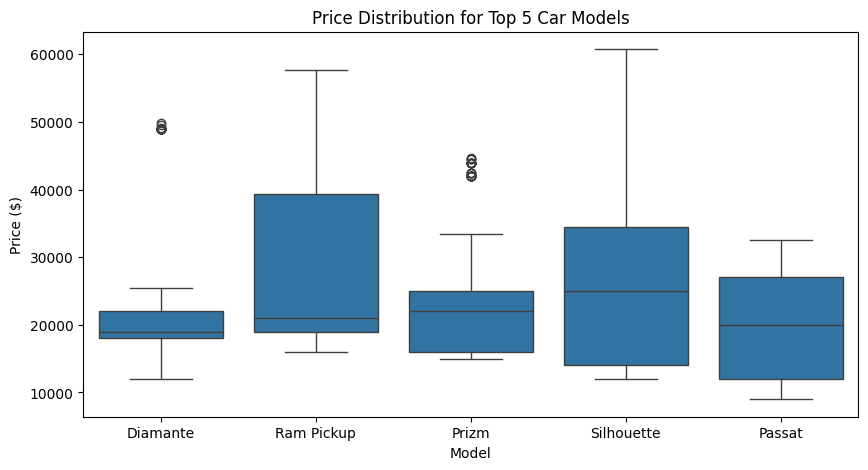

In [31]:
# Q10: Top 5 car models by sales and price distribution
top_models = car_df['Model'].value_counts().head(5).index
top_model_df = car_df[car_df['Model'].isin(top_models)]
plt.figure(figsize=(10,5))
sns.boxplot(data=top_model_df, x='Model', y='Price ($)')
plt.title('Price Distribution for Top 5 Car Models')
plt.show()

Color
Red           15519.360962
Black         15286.065976
Pale White    14077.346859
Name: Price ($), dtype: float64


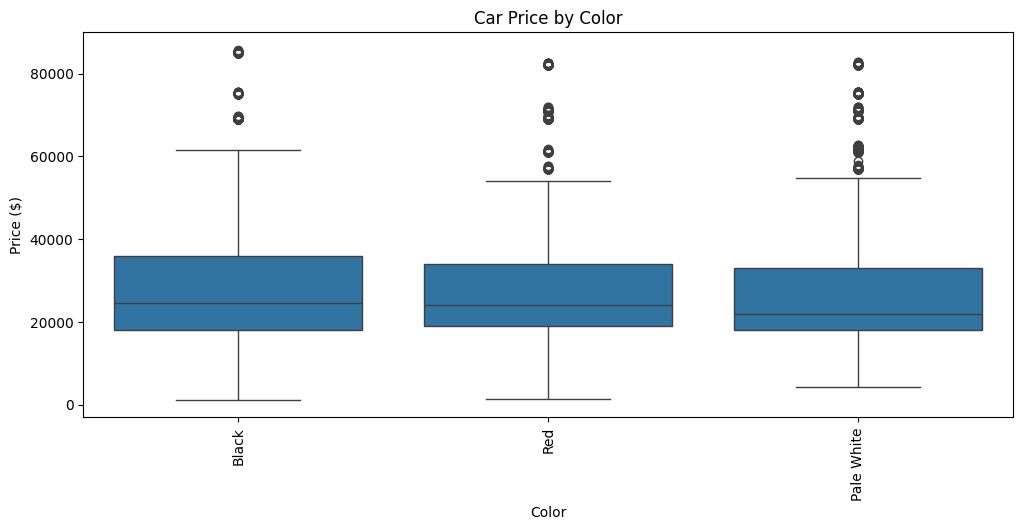

In [32]:
# Q11: Car price vs engine size across colors, color with highest price variation
color_var = car_df.groupby('Color')['Price ($)'].std().sort_values(ascending=False)
print(color_var.head())
plt.figure(figsize=(12,5))
sns.boxplot(data=car_df, x='Color', y='Price ($)')
plt.xticks(rotation=90)
plt.title('Car Price by Color')
plt.show()

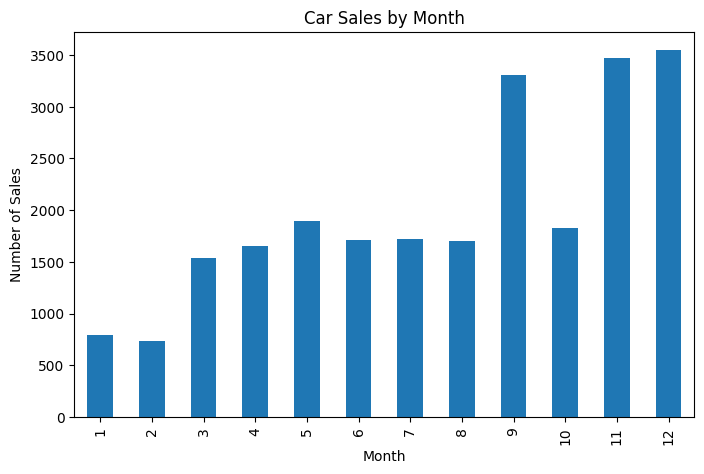

In [33]:
# Q12: Seasonal trend in car sales by date
car_df['Date'] = pd.to_datetime(car_df['Date'], errors='coerce')
car_df['Month'] = car_df['Date'].dt.month
monthly_sales = car_df['Month'].value_counts().sort_index()
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.show()

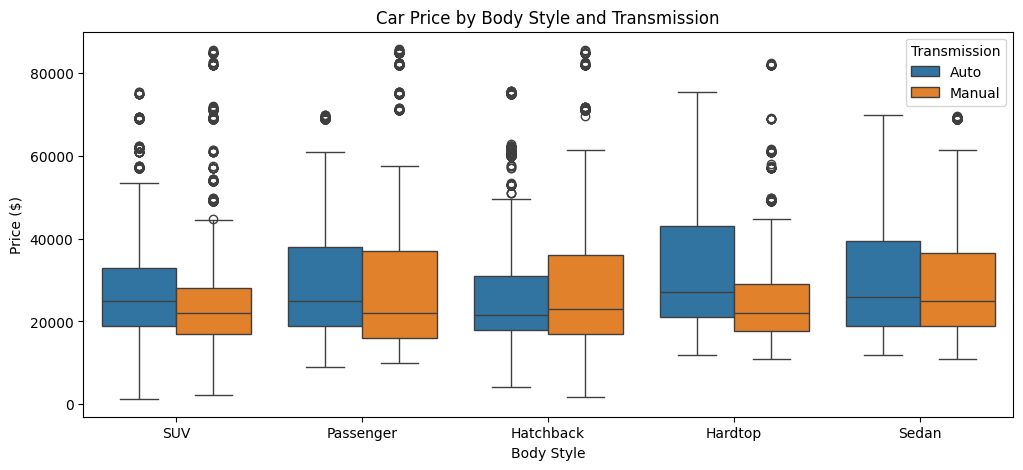

In [34]:
# Q13: Car price by body style and transmission
plt.figure(figsize=(12,5))
sns.boxplot(data=car_df, x='Body Style', y='Price ($)', hue='Transmission')
plt.title('Car Price by Body Style and Transmission')
plt.show()

In [35]:
# Q14: Correlation between car price, engine size, and annual income
corr_car = car_df[['Price ($)', 'Annual Income']].corr()
print(corr_car)
# Engine size is categorical, so not included in correlation

               Price ($)  Annual Income
Price ($)       1.000000       0.012065
Annual Income   0.012065       1.000000


In [36]:
# Q15: Average car price by model and engine type
avg_price_model_engine = car_df.groupby(['Model', 'Engine'])['Price ($)'].mean().unstack()
print(avg_price_model_engine.head())

Engine  DoubleÂ Overhead Camshaft  Overhead Camshaft
Model                                               
3-Sep                37986.380117                NaN
3000GT               22764.326923       21770.659864
300M                 21394.888889                NaN
323i                 16744.632287       21038.162162
328i                 21069.149606       38676.177215


---
## Dataset 3: Amazon Sales Data

In [37]:
# Load Amazon Sales dataset
amazon_df = pd.read_csv('datasets/amazon.csv')
amazon_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [38]:
# Q1: Average rating for each product category
amazon_df['category'] = amazon_df['category'].astype(str)
amazon_df['rating'] = pd.to_numeric(amazon_df['rating'], errors='coerce')
avg_rating_cat = amazon_df.groupby('category')['rating'].mean().sort_values(ascending=False)
print(avg_rating_cat)

category
Computers&Accessories|Tablets                                                                                    4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters                                         4.5
Electronics|Cameras&Photography|Accessories|Film                                                                 4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                                                     4.5
OfficeProducts|OfficeElectronics|Calculators|Basic                                                               4.5
                                                                                                                ... 
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                               3.6
Electronics|HomeTheater,TV&Video|Accessories|3DGlasses                                                           3.5
Computers&Accessories|Accessories&Peripherals|Audio&Vid

In [39]:
# Q2: Top rating_count products by category
amazon_df['rating_count'] = pd.to_numeric(amazon_df['rating_count'], errors='coerce')
top_rating_count = amazon_df.groupby('category').apply(lambda x: x.nlargest(1, 'rating_count'))
print(top_rating_count[['product_name', 'rating_count']])

                                                                                              product_name  \
category                                                                                                     
Car&Motorbike|CarAccessories|InteriorAccessorie... 1157  Reffair AX30 [MAX] Portable Air Purifier for C...   
Computers&Accessories|Accessories&Peripherals|A... 695   rts [2 Pack] Mini USB C Type C Adapter Plug, T...   
Computers&Accessories|Accessories&Peripherals|A... 906   Hp Wired On Ear Headphones With Mic With 3.5 M...   
Computers&Accessories|Accessories&Peripherals|A... 748   JBL Commercial CSLM20B Auxiliary Omnidirection...   
Computers&Accessories|Accessories&Peripherals|A... 844   Zebronics Zeb Wonderbar 10 USB Powered 2.0 Com...   
...                                                                                                    ...   
OfficeProducts|OfficePaperProducts|Paper|Statio... 616   Classmate Octane Neon- Blue Gel Pens(Pack of 5...   
OfficeProd

C:\Users\Piyush Mishra\AppData\Local\Temp\ipykernel_16744\257709120.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_rating_count = amazon_df.groupby('category').apply(lambda x: x.nlargest(1, 'rating_count'))


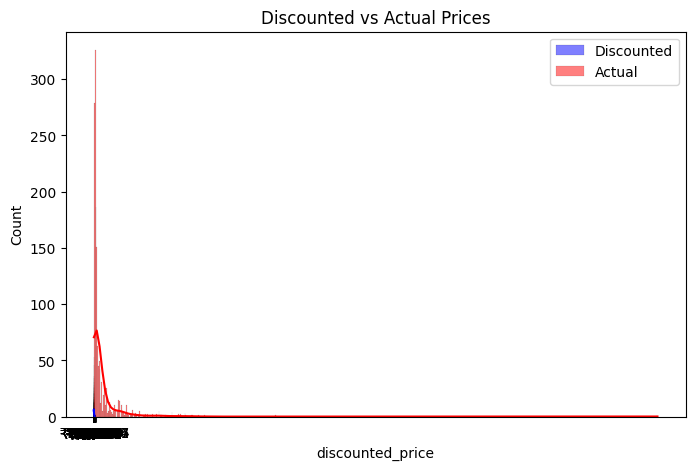

In [40]:
# Q3: Distribution of discounted vs actual prices
plt.figure(figsize=(8,5))
sns.histplot(amazon_df['discounted_price'], color='blue', label='Discounted', kde=True)
sns.histplot(amazon_df['actual_price'].replace('[^0-9]', '', regex=True).astype(float), color='red', label='Actual', kde=True)
plt.legend()
plt.title('Discounted vs Actual Prices')
plt.show()

In [41]:
# Q4: Average discount percentage by category
amazon_df['discount_percentage'] = amazon_df['discount_percentage'].str.replace('%', '').astype(float)
avg_discount_cat = amazon_df.groupby('category')['discount_percentage'].mean().sort_values(ascending=False)
print(avg_discount_cat)

category
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                                 90.0
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                          90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                                  90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                                 88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers       87.5
                                                                                                                    ... 
OfficeProducts|OfficeElectronics|Calculators|Basic                                                                   0.0
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|SmallApplianceParts&Accessories|StandMixerAccessories     0.0
Electronics|HomeAudio|M

In [42]:
# Q5: Most popular product names
popular_products = amazon_df['product_name'].value_counts().head(10)
print(popular_products)

product_name
Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution             5
Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating                      4
Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)    3
MI Braided USB Type-C Cable for Charging Adapter (Red)                                                                                                                3
Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)                                       3
Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB Storage) | 5000mAh Battery | Upto 12GB RAM with RAM Plus                                             

In [43]:
# Q6: Most popular product keywords
from collections import Counter
keywords = amazon_df['about_product'].dropna().str.cat(sep='|').split('|')
keyword_counts = Counter(keywords)
print(keyword_counts.most_common(10))

[(' 178 Degree wide viewing angle', 29), (' 2 USB ports to connect hard drives and other USB devices ', 26), ('Easy Returns: This product is eligible for replacement within 10 days of delivery in case of any product defects, damage or features not matching the description', 24), (' Refresh Rate : 60 Hertz ', 21), (' Chromecast built-in ', 18), ('2 years warranty from the date of purchase', 15), ('1 year warranty from the date of purchase', 15), (' Google Assistant ', 14), ('', 14), (' Bluetooth 5.0 ', 13)]


In [44]:
# Q7: Most popular product reviews
popular_reviews = amazon_df['review_content'].value_counts().head(10)
print(popular_reviews)

review_content
I am not big on camera usage, personally. I was even mentally prepared for a bad camera, based on some reviews here. But I was pleasantly surprised that camera clicks good photos. They are not awesome, but they are decent photos that can even be shared.Now coming to my biggest grouse; heating issue. The phone started heating up while charging, but it was just a little and so I could have ignored it. But then it started heating up more and got me very concerned. I even ordered a replacement thinking I got a defective piece. But then, after further tests, I found that it is heating more when I download huge amounts of data, for example, when I restore data of my old phone, from back up. This is ok with me as, I don't perform huge data loads regularly, definitely not on phone. Then I tested by running tasks I usually perform such as checking office mails, attending office meeting on phone, watching a video from Amazon Prime, and so on. The phone did not heat up even a littl

In [45]:
# Q8: Correlation between discounted_price and rating
amazon_df['discounted_price'] = amazon_df['discounted_price'].replace('[^0-9.]', '', regex=True).astype(float)
corr_discount_rating = amazon_df[['discounted_price', 'rating']].corr()
print(corr_discount_rating)

                  discounted_price    rating
discounted_price          1.000000  0.120337
rating                    0.120337  1.000000


In [46]:
# Q9: Top 5 categories by highest ratings
top5_cat = avg_rating_cat.head(5)
print(top5_cat)

category
Computers&Accessories|Tablets                                               4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters    4.5
Electronics|Cameras&Photography|Accessories|Film                            4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                4.5
OfficeProducts|OfficeElectronics|Calculators|Basic                          4.5
Name: rating, dtype: float64


In [47]:
# Q10: Areas for improvement/optimization
missing = amazon_df.isnull().sum()
print('Missing values by column:')
print(missing)
print('Consider optimizing products with low ratings, high discounts, or low review counts.')

Missing values by column:
product_id                0
product_name              0
category                  0
discounted_price          0
actual_price              0
discount_percentage       0
rating                    1
rating_count           1139
about_product             0
user_id                   0
user_name                 0
review_id                 0
review_title              0
review_content            0
img_link                  0
product_link              0
dtype: int64
Consider optimizing products with low ratings, high discounts, or low review counts.

product_id                0
product_name              0
category                  0
discounted_price          0
actual_price              0
discount_percentage       0
rating                    1
rating_count           1139
about_product             0
user_id                   0
user_name                 0
review_id                 0
review_title              0
review_content            0
img_link                  0
product

---
## Dataset 4: Spotify Data (Popular Hip-Hop Artists and Tracks)

In [48]:
# Load Spotify dataset
spotify_df = pd.read_csv('datasets/spotify.csv')
spotify_df.head()

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


In [49]:
# Q1: Check nulls and duplicates
print('Null values:')
print(spotify_df.isnull().sum())
print('Duplicates:', spotify_df.duplicated().sum())
spotify_df = spotify_df.drop_duplicates()

Null values:
Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Duplicates: 27
Duplicates: 27


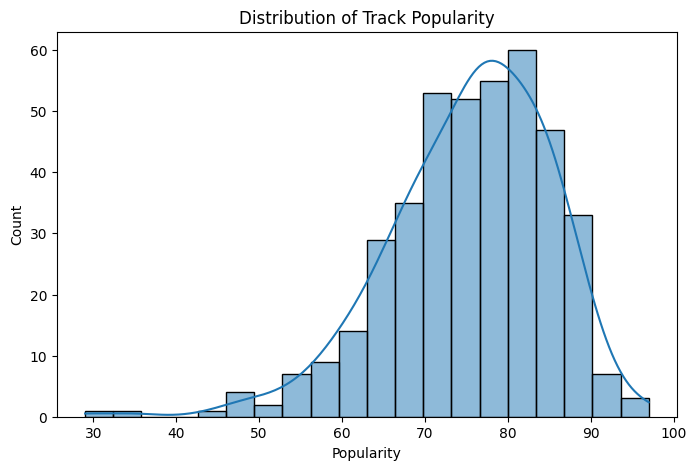

In [50]:
# Q2: Distribution of popularity (histogram)
plt.figure(figsize=(8,5))
sns.histplot(spotify_df['Popularity'], bins=20, kde=True)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.show()

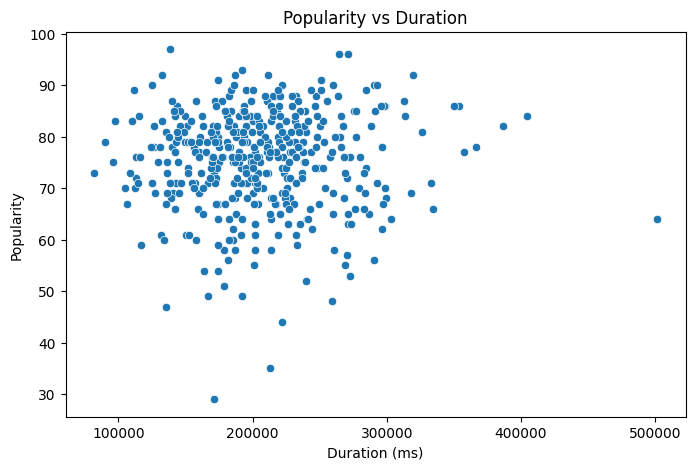

In [51]:
# Q3: Relationship between popularity and duration (scatter plot)
plt.figure(figsize=(8,5))
sns.scatterplot(data=spotify_df, x='Duration (ms)', y='Popularity')
plt.title('Popularity vs Duration')
plt.show()

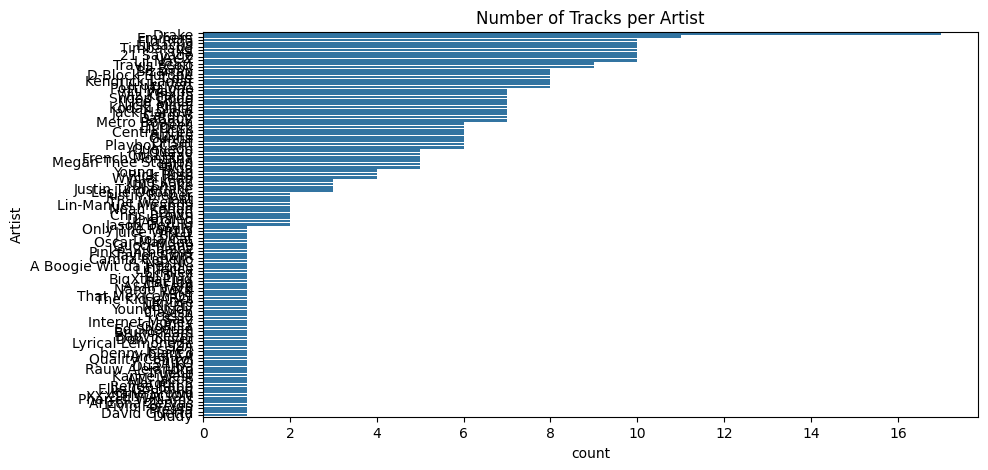

In [52]:
# Q4: Artist with highest number of tracks (countplot)
plt.figure(figsize=(10,5))
sns.countplot(data=spotify_df, y='Artist', order=spotify_df['Artist'].value_counts().index)
plt.title('Number of Tracks per Artist')
plt.show()

In [53]:
# Q5: Top 5 least popular tracks
least_popular = spotify_df.nsmallest(5, 'Popularity')[['Artist', 'Track Name', 'Popularity']]
print(least_popular)

             Artist                     Track Name  Popularity
207          Pressa  Attachments (feat. Coi Leray)          29
231   Justin Bieber                     Intentions          35
413  French Montana                Splash Brothers          44
225        Lil Baby                  On Me - Remix          47
407     Wyclef Jean      911 (feat. Mary J. Blige)          48


In [54]:
# Q6: Top 5 most popular artists and their average popularity
top_artists = spotify_df['Artist'].value_counts().head(5).index
avg_pop_top = spotify_df[spotify_df['Artist'].isin(top_artists)].groupby('Artist')['Popularity'].mean()
print(avg_pop_top)

Artist
Drake        82.882353
Eminem       83.636364
Flo Rida     78.000000
Ludacris     63.000000
Timbaland    69.000000
Name: Popularity, dtype: float64


In [55]:
# Q7: Most popular tracks for top 5 artists
# Ensure spotify_df is defined
try:
    spotify_df
except NameError:
    spotify_df = pd.read_csv('datasets/spotify.csv')

top_artists = spotify_df['Artist'].value_counts().head(5).index

for artist in top_artists:
    top_track = spotify_df[spotify_df['Artist'] == artist].nlargest(1, 'Popularity')[['Track Name', 'Popularity']]
    print(f"{artist}: {top_track.iloc[0]['Track Name']} ({top_track.iloc[0]['Popularity']})")

Drake: Rich Baby Daddy (feat. Sexyy Red & SZA) (92)
Eminem: Without Me (90)
Flo Rida: Low (feat. T-Pain) (84)
Ludacris: My Chick Bad (67)
Timbaland: The Way I Are (85)


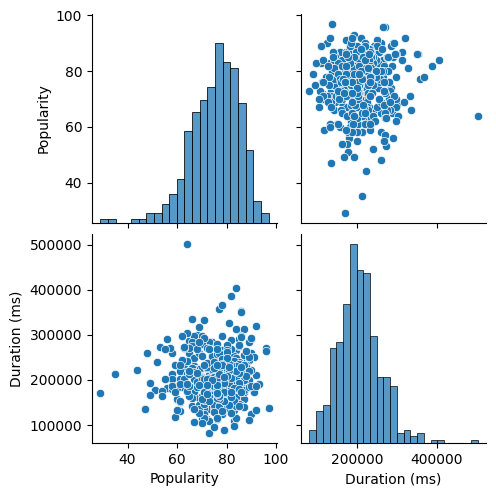

In [56]:
# Q8: Pair plot for numerical variables
sns.pairplot(spotify_df[['Popularity', 'Duration (ms)']])
plt.show()

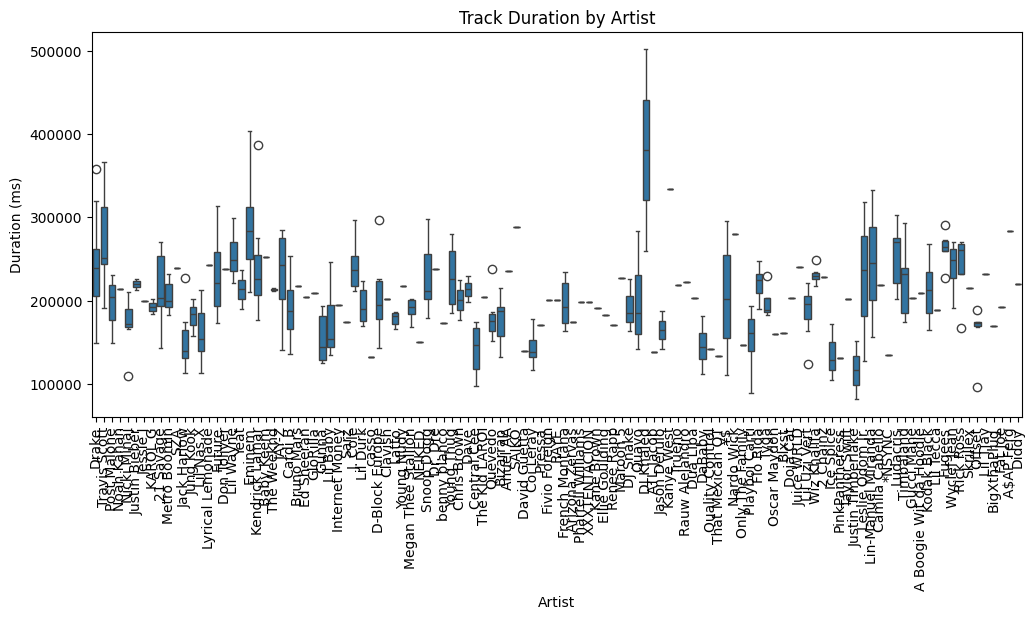

In [57]:
# Q9: Duration of tracks by artist (box plot)
plt.figure(figsize=(12,5))
sns.boxplot(data=spotify_df, x='Artist', y='Duration (ms)')
plt.xticks(rotation=90)
plt.title('Track Duration by Artist')
plt.show()

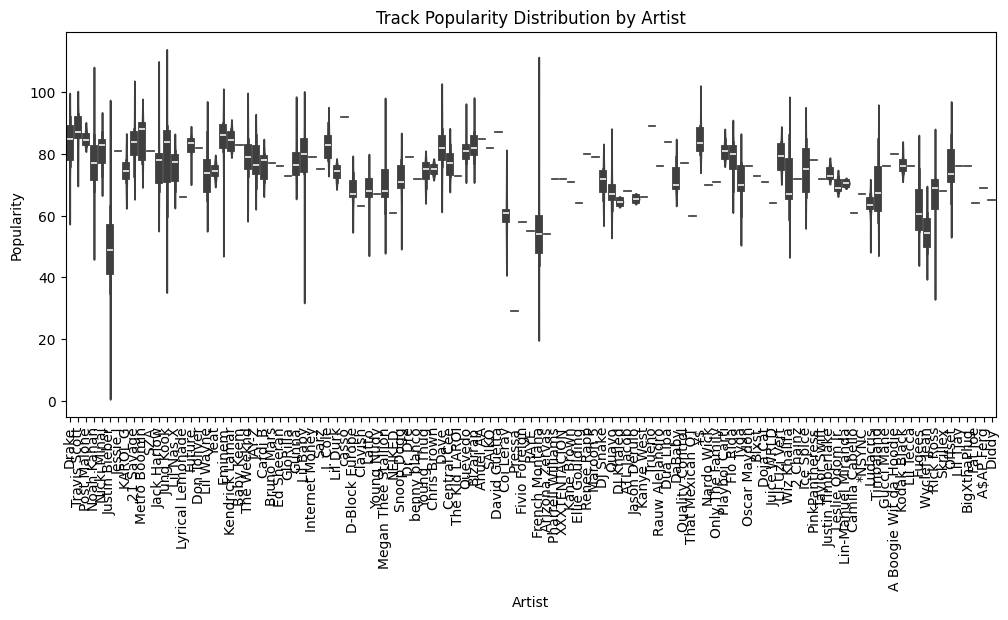

In [58]:
# Q10: Distribution of track popularity by artist (violin plot)
plt.figure(figsize=(12,5))
sns.violinplot(data=spotify_df, x='Artist', y='Popularity')
plt.xticks(rotation=90)
plt.title('Track Popularity Distribution by Artist')
plt.show()